# E7 - Inventario SSMSpine / SymTC

Este notebook inventaria SSMSpine/SymTC como posible dataset adicional para segmentacion lumbar. La hipotesis inicial es que SSMSpine parece sintetico y mid-sagittal, no axial. El objetivo es verificarlo tecnicamente con inventario, lectura `.pt`, visualizaciones, analisis de labels y una decision conservadora para el proyecto.

No se entrenan modelos en este notebook.

In [1]:
try:
    import torch  # noqa: F401
except Exception:
    %pip install -q torch

In [2]:
try:
    import torch  # noqa
except Exception:
    %pip install -q torch

import json
import zipfile
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 160)

## Montaje de Drive y rutas

In [3]:
from google.colab import drive
drive.mount("/content/drive")

SSMSPINE_ROOT = Path("/content/drive/MyDrive/PFI_MVP/data/SSMSPINE")
RAW_ZIPS = SSMSPINE_ROOT / "raw_zips"
EXTRACTED_ROOT = SSMSPINE_ROOT / "extracted"
PROCESSED_ROOT = SSMSPINE_ROOT / "processed"

RESULTS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E7_ssmspine_inventory")
FIGURES_ROOT = Path("/content/drive/MyDrive/PFI_MVP/figures")
DOCS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/docs")

for path in [RAW_ZIPS, EXTRACTED_ROOT, PROCESSED_ROOT, RESULTS_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_SAMPLE_ZIPS = [
    "SSMSpine_Train_Sample.zip",
    "SSMSpine_Test_Sample.zip",
]

EXPECTED_FULL_ZIPS = [
    "SSMSpine_Train.zip",
    "SSMSpine_Test.zip",
]

EXTRACT_SAMPLE_ZIPS = True
EXTRACT_FULL_DATASET = False
FORCE_DOWNLOAD = False
FORCE_EXTRACT = False

PT_SAMPLE_N = 20
VIS_SAMPLE_N = 10
LABEL_SAMPLE_N = 100
RANDOM_SEED = 42

print("SSMSPINE_ROOT:", SSMSPINE_ROOT)
print("RAW_ZIPS:", RAW_ZIPS)
print("EXTRACTED_ROOT:", EXTRACTED_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SSMSPINE_ROOT: /content/drive/MyDrive/PFI_MVP/data/SSMSPINE
RAW_ZIPS: /content/drive/MyDrive/PFI_MVP/data/SSMSPINE/raw_zips
EXTRACTED_ROOT: /content/drive/MyDrive/PFI_MVP/data/SSMSPINE/extracted
RESULTS_ROOT: /content/drive/MyDrive/PFI_MVP/results/E7_ssmspine_inventory


## Verificacion de ZIPs

In [4]:
!pip -q install gdown

download_links = {
    "SSMSpine_Train_Sample.zip": "https://drive.google.com/file/d/17hDyZ9CdtA-yKQ95qCN-cRDZWjdPL2Mb/view?usp=sharing",
    "SSMSpine_Test_Sample.zip": "https://drive.google.com/file/d/1raxSVmP3cauQUdBASXbZjhjdGQCjWbkL/view?usp=sharing",
}

for zip_name, url in download_links.items():
    output_path = RAW_ZIPS / zip_name

    if output_path.exists() and output_path.stat().st_size > 0 and not FORCE_DOWNLOAD:
        print("Ya existe, no se descarga:", output_path.name, round(output_path.stat().st_size / (1024**2), 2), "MB")
        continue

    print("Descargando:", zip_name)
    !gdown --fuzzy "{url}" -O "{output_path}"

print("\nContenido final de raw_zips:")
for p in sorted(RAW_ZIPS.glob("*")):
    print("-", p.name, "|", round(p.stat().st_size / (1024**2), 2), "MB")

Ya existe, no se descarga: SSMSpine_Train_Sample.zip 211.44 MB
Ya existe, no se descarga: SSMSpine_Test_Sample.zip 269.75 MB

Contenido final de raw_zips:
- SSMSpine_Test_Sample.zip | 269.75 MB
- SSMSpine_Train_Sample.zip | 211.44 MB


In [5]:
def human_size(num_bytes):
    value = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if value < 1024 or unit == "TB":
            return f"{value:.2f} {unit}"
        value /= 1024

zip_names_to_check = EXPECTED_SAMPLE_ZIPS + EXPECTED_FULL_ZIPS

zip_rows = []

for name in zip_names_to_check:
    path = RAW_ZIPS / name
    detected = path.exists()

    zip_rows.append({
        "zip_name": name,
        "zip_path": str(path),
        "detected": bool(detected),
        "size_bytes": int(path.stat().st_size) if detected else 0,
        "size_human": human_size(path.stat().st_size) if detected else "0 B",
        "expected_sample": name in EXPECTED_SAMPLE_ZIPS,
        "expected_full": name in EXPECTED_FULL_ZIPS,
    })

for path in sorted(RAW_ZIPS.glob("*.zip")):
    if path.name not in zip_names_to_check:
        zip_rows.append({
            "zip_name": path.name,
            "zip_path": str(path),
            "detected": True,
            "size_bytes": int(path.stat().st_size),
            "size_human": human_size(path.stat().st_size),
            "expected_sample": False,
            "expected_full": False,
        })

zip_files_df = pd.DataFrame(zip_rows)

zip_files_csv_path = RESULTS_ROOT / "E7_ssmspine_zip_files.csv"
zip_files_df.to_csv(zip_files_csv_path, index=False)

display(zip_files_df)

missing_samples = zip_files_df[
    zip_files_df["expected_sample"] & ~zip_files_df["detected"]
]["zip_name"].tolist()

if missing_samples:
    raise FileNotFoundError(f"Faltan ZIPs sample esperados: {missing_samples}")

,zip_name,zip_path,detected,size_bytes,size_human,expected_sample,expected_full
0,SSMSpine_Train_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,True,221714714,211.44 MB,True,False
1,SSMSpine_Test_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,True,282858572,269.75 MB,True,False
2,SSMSpine_Train.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,False,0,0 B,False,True
3,SSMSpine_Test.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,False,0,0 B,False,True


## Inventario interno de ZIPs

In [6]:
def human_size(num_bytes):
    value = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if value < 1024 or unit == "TB":
            return f"{value:.2f} {unit}"
        value /= 1024

zip_names_to_check = EXPECTED_SAMPLE_ZIPS + EXPECTED_FULL_ZIPS

zip_rows = []

for name in zip_names_to_check:
    path = RAW_ZIPS / name
    detected = path.exists()

    zip_rows.append({
        "zip_name": name,
        "zip_path": str(path),
        "detected": bool(detected),
        "size_bytes": int(path.stat().st_size) if detected else 0,
        "size_human": human_size(path.stat().st_size) if detected else "0 B",
        "expected_sample": name in EXPECTED_SAMPLE_ZIPS,
        "expected_full": name in EXPECTED_FULL_ZIPS,
    })

for path in sorted(RAW_ZIPS.glob("*.zip")):
    if path.name not in zip_names_to_check:
        zip_rows.append({
            "zip_name": path.name,
            "zip_path": str(path),
            "detected": True,
            "size_bytes": int(path.stat().st_size),
            "size_human": human_size(path.stat().st_size),
            "expected_sample": False,
            "expected_full": False,
        })

zip_files_df = pd.DataFrame(zip_rows)

zip_files_csv_path = RESULTS_ROOT / "E7_ssmspine_zip_files.csv"
zip_files_df.to_csv(zip_files_csv_path, index=False)

display(zip_files_df)

missing_samples = zip_files_df[
    zip_files_df["expected_sample"] & ~zip_files_df["detected"]
]["zip_name"].tolist()

if missing_samples:
    raise FileNotFoundError(f"Faltan ZIPs sample esperados: {missing_samples}")

,zip_name,zip_path,detected,size_bytes,size_human,expected_sample,expected_full
0,SSMSpine_Train_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,True,221714714,211.44 MB,True,False
1,SSMSpine_Test_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,True,282858572,269.75 MB,True,False
2,SSMSpine_Train.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,False,0,0 B,False,True
3,SSMSpine_Test.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,False,0,0 B,False,True


## Extraccion controlada

In [7]:
def count_zip_extensions(zip_path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        infos = [info for info in zf.infolist() if not info.is_dir()]
        names = [info.filename for info in infos]

    counts = {".pt": 0, ".pth": 0, ".png": 0, ".json": 0, ".csv": 0, "other": 0}

    for name in names:
        ext = Path(name).suffix.lower()
        if ext in counts:
            counts[ext] += 1
        else:
            counts["other"] += 1

    all_text = " ".join(names).lower()

    return {
        "total_files": len(names),
        "count_pt": counts[".pt"],
        "count_pth": counts[".pth"],
        "count_png": counts[".png"],
        "count_json": counts[".json"],
        "count_csv": counts[".csv"],
        "count_other": counts["other"],
        "example_internal_paths": json.dumps(names[:25], ensure_ascii=False),
        "has_train": "train" in all_text,
        "has_test": "test" in all_text,
        "has_sample": "sample" in all_text,
    }

zip_inventory_rows = []

for _, row in zip_files_df[zip_files_df["detected"]].iterrows():
    zip_path = Path(row["zip_path"])

    try:
        stats = count_zip_extensions(zip_path)
        zip_inventory_rows.append({
            "zip_name": row["zip_name"],
            "zip_path": str(zip_path),
            "read_ok": True,
            "error": None,
            **stats,
        })
    except Exception as exc:
        zip_inventory_rows.append({
            "zip_name": row["zip_name"],
            "zip_path": str(zip_path),
            "read_ok": False,
            "error": repr(exc),
        })

zip_inventory_df = pd.DataFrame(zip_inventory_rows)

zip_inventory_csv_path = RESULTS_ROOT / "E7_ssmspine_zip_inventory.csv"
zip_inventory_df.to_csv(zip_inventory_csv_path, index=False)

display(zip_inventory_df)

,zip_name,zip_path,read_ok,error,total_files,count_pt,count_pth,count_png,count_json,count_csv,count_other,example_internal_paths,has_train,has_test,has_sample
0,SSMSpine_Train_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,True,None,125,125,0,0,0,0,0,"[""SSMSpine_Train_Sample/p0/aug0.pt"", ""SSMSpine...",True,False,True
1,SSMSpine_Test_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,True,None,125,125,0,0,0,0,0,"[""SSMSpine_Test_Sample/p80/aug0.pt"", ""SSMSpine...",False,True,True


## Inventario extraido

In [8]:
def safe_extract_zip(zip_path, destination):
    destination = Path(destination).resolve()

    with zipfile.ZipFile(zip_path, "r") as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if not str(target).startswith(str(destination)):
                raise RuntimeError(f"Ruta insegura en ZIP: {member.filename}")

        zf.extractall(destination)

extract_rows = []

for _, row in zip_files_df[zip_files_df["detected"]].iterrows():
    name = row["zip_name"]
    zip_path = Path(row["zip_path"])

    should_extract = (
        (name in EXPECTED_SAMPLE_ZIPS and EXTRACT_SAMPLE_ZIPS)
        or (name in EXPECTED_FULL_ZIPS and EXTRACT_FULL_DATASET)
    )

    destination = EXTRACTED_ROOT / Path(name).stem

    if FORCE_EXTRACT and destination.exists():
        shutil.rmtree(destination)

    destination.mkdir(parents=True, exist_ok=True)

    existing_files = [p for p in destination.rglob("*") if p.is_file()]
    skipped_existing = bool(existing_files and not FORCE_EXTRACT)

    error = None
    extracted_count = len(existing_files)

    if should_extract:
        try:
            if not skipped_existing:
                print("Extrayendo:", zip_path.name, "->", destination)
                safe_extract_zip(zip_path, destination)
                extracted_count = sum(1 for p in destination.rglob("*") if p.is_file())
            else:
                print("Ya extraído, se omite:", destination)

        except Exception as exc:
            error = repr(exc)

    extract_rows.append({
        "zip_name": name,
        "zip_path": str(zip_path),
        "destination": str(destination),
        "should_extract": bool(should_extract),
        "skipped_existing": bool(skipped_existing),
        "force_extract": FORCE_EXTRACT,
        "extracted_file_count": int(extracted_count),
        "error": error,
    })

extraction_report_df = pd.DataFrame(extract_rows)

extraction_report_csv_path = RESULTS_ROOT / "E7_ssmspine_extraction_report.csv"
extraction_report_df.to_csv(extraction_report_csv_path, index=False)

display(extraction_report_df)

if extraction_report_df["error"].notna().any():
    print("Hubo errores de extracción:")
    display(extraction_report_df[extraction_report_df["error"].notna()])

Extrayendo: SSMSpine_Train_Sample.zip -> /content/drive/MyDrive/PFI_MVP/data/SSMSPINE/extracted/SSMSpine_Train_Sample
Extrayendo: SSMSpine_Test_Sample.zip -> /content/drive/MyDrive/PFI_MVP/data/SSMSPINE/extracted/SSMSpine_Test_Sample


,zip_name,zip_path,destination,should_extract,skipped_existing,force_extract,extracted_file_count,error
0,SSMSpine_Train_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,True,False,False,125,None
1,SSMSpine_Test_Sample.zip,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/r...,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,True,False,False,125,None


In [9]:
def infer_split_candidate(relative_path):
    text = str(relative_path).lower()
    if "train" in text:
        return "train"
    if "test" in text:
        return "test"
    return "unknown"

def infer_sample_or_full(relative_path):
    text = str(relative_path).lower()
    if "sample" in text:
        return "sample"
    return "unknown_or_full"

file_rows = []

all_files = [p for p in EXTRACTED_ROOT.rglob("*") if p.is_file()]
print("Archivos encontrados en EXTRACTED_ROOT:", len(all_files))

for p in all_files:
    try:
        rel = p.relative_to(EXTRACTED_ROOT)
    except Exception:
        rel = p.name

    file_rows.append({
        "file_path": str(p),
        "relative_path": str(rel),
        "file_name": p.name,
        "extension": p.suffix.lower(),
        "parent_folder": p.parent.name,
        "size_bytes": p.stat().st_size,
        "split_candidate": infer_split_candidate(rel),
        "sample_or_full": infer_sample_or_full(rel),
        "patient_folder_candidate": p.parent.name,
        "augmentation_candidate": None,
    })

extracted_inventory_df = pd.DataFrame(file_rows)

expected_cols = [
    "file_path",
    "relative_path",
    "file_name",
    "extension",
    "parent_folder",
    "size_bytes",
    "split_candidate",
    "sample_or_full",
    "patient_folder_candidate",
    "augmentation_candidate",
]

for col in expected_cols:
    if col not in extracted_inventory_df.columns:
        extracted_inventory_df[col] = None

extracted_inventory_csv_path = RESULTS_ROOT / "E7_ssmspine_extracted_file_inventory.csv"
extracted_inventory_df.to_csv(extracted_inventory_csv_path, index=False)

print("Inventario extraído:", extracted_inventory_csv_path)
print("Total archivos:", len(extracted_inventory_df))

if len(extracted_inventory_df):
    ext_counts_df = (
        extracted_inventory_df["extension"]
        .value_counts()
        .rename_axis("extension")
        .reset_index(name="n_files")
    )
    display(ext_counts_df)
    display(extracted_inventory_df.head())
else:
    raise RuntimeError("No se encontraron archivos extraídos. Revisar extracción.")

Archivos encontrados en EXTRACTED_ROOT: 250
Inventario extraído: /content/drive/MyDrive/PFI_MVP/results/E7_ssmspine_inventory/E7_ssmspine_extracted_file_inventory.csv
Total archivos: 250


,extension,n_files
0,.pt,250


,file_path,relative_path,file_name,extension,parent_folder,size_bytes,split_candidate,sample_or_full,patient_folder_candidate,augmentation_candidate
0,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,aug0.pt,.pt,p0,29551791,train,sample,p0,None
1,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,aug1.pt,.pt,p0,29460271,train,sample,p0,None
2,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,aug10.pt,.pt,p0,29452975,train,sample,p0,None
3,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,aug100.pt,.pt,p0,29477423,train,sample,p0,None
4,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,aug101.pt,.pt,p0,29478511,train,sample,p0,None


## Lectura de archivos PT

In [10]:
def to_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    if isinstance(value, np.ndarray):
        return value
    return None

def summarize_pt_value(value):
    arr = to_numpy(value)

    if arr is None:
        return {
            "shape": None,
            "dtype": str(type(value)),
            "min": None,
            "max": None,
        }

    numeric = np.issubdtype(arr.dtype, np.number)

    return {
        "shape": str(tuple(arr.shape)),
        "dtype": str(arr.dtype),
        "min": float(np.nanmin(arr)) if numeric and arr.size else None,
        "max": float(np.nanmax(arr)) if numeric and arr.size else None,
    }

def torch_load_safe(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

pt_files_df = extracted_inventory_df[
    extracted_inventory_df["extension"].astype(str).str.lower().isin([".pt", ".pth"])
].copy()

print("Archivos PT/PTH encontrados:", len(pt_files_df))

pt_sample_df = (
    pt_files_df.sample(
        n=min(PT_SAMPLE_N, len(pt_files_df)),
        random_state=RANDOM_SEED
    )
    if len(pt_files_df)
    else pd.DataFrame()
)

pt_summary_rows = []
loaded_samples = []

for _, row in tqdm(pt_sample_df.iterrows(), total=len(pt_sample_df), desc="Leyendo PT sample"):
    item = {
        "file_path": row["file_path"],
        "relative_path": row["relative_path"],
        "read_ok": False,
        "error": None,
    }

    try:
        data = torch_load_safe(row["file_path"])

        if isinstance(data, dict):
            keys = list(data.keys())
        else:
            keys = []

        item["read_ok"] = True
        item["root_type"] = str(type(data))
        item["keys"] = json.dumps([str(k) for k in keys], ensure_ascii=False)

        for key in keys:
            s = summarize_pt_value(data[key])
            safe_key = str(key).replace(" ", "_")
            item[f"{safe_key}_shape"] = s["shape"]
            item[f"{safe_key}_dtype"] = s["dtype"]
            item[f"{safe_key}_min"] = s["min"]
            item[f"{safe_key}_max"] = s["max"]

        for k in ["img", "img_corrected", "img_equalized", "label", "mask", "bone_mask", "disk_mask"]:
            item[f"has_{k}"] = k in keys

        item["has_landmarks"] = any("landmark" in str(k).lower() for k in keys)

        loaded_samples.append((row.to_dict(), data))

    except Exception as exc:
        item["error"] = repr(exc)

    pt_summary_rows.append(item)

pt_sample_summary_df = pd.DataFrame(pt_summary_rows)

pt_sample_summary_csv_path = RESULTS_ROOT / "E7_ssmspine_pt_sample_summary.csv"
pt_sample_summary_df.to_csv(pt_sample_summary_csv_path, index=False)

print("CSV:", pt_sample_summary_csv_path)
print("Samples cargadas OK:", int(pt_sample_summary_df["read_ok"].sum()) if len(pt_sample_summary_df) else 0)

display(pt_sample_summary_df.head())

Archivos PT/PTH encontrados: 250


Leyendo PT sample:   0%|          | 0/20 [00:00<?, ?it/s]

CSV: /content/drive/MyDrive/PFI_MVP/results/E7_ssmspine_inventory/E7_ssmspine_pt_sample_summary.csv
Samples cargadas OK: 20


,file_path,relative_path,read_ok,error,root_type,keys,img_shape,img_dtype,img_min,img_max,img_equalized_shape,img_equalized_dtype,img_equalized_min,img_equalized_max,img_corrected_shape,img_corrected_dtype,img_corrected_min,img_corrected_max,shape_shape,shape_dtype,shape_min,shape_max,bone_shape,bone_dtype,bone_min,bone_max,disk_shape,disk_dtype,disk_min,disk_max,bone_mask_shape,bone_mask_dtype,bone_mask_min,bone_mask_max,disk_mask_shape,disk_mask_dtype,disk_mask_min,disk_mask_max,mask_shape,mask_dtype,mask_min,mask_max,label_shape,label_dtype,label_min,label_max,has_img,has_img_corrected,has_img_equalized,has_label,has_mask,has_bone_mask,has_disk_mask,has_landmarks
0,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Test_Sample/SSMSpine_Test_Sample/p80/...,True,None,<class 'dict'>,"[""img"", ""img_equalized"", ""img_corrected"", ""sha...","(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(1696, 2)",float32,90.801949,395.378937,"(6, 236, 2)",float64,90.801949,391.804810,"(5, 176, 2)",float64,128.141525,395.378937,"(6, 512, 512)",float32,0.0,1.0,"(5, 512, 512)",float32,0.0,1.0,"(11, 512, 512)",float32,0.0,1.0,"(1, 512, 512)",float64,0.0,11.0,True,True,True,True,True,True,True,False
1,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,<class 'dict'>,"[""img"", ""img_equalized"", ""img_corrected"", ""sha...","(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(1696, 2)",float32,79.221352,407.116699,"(6, 236, 2)",float64,79.221352,407.116699,"(5, 176, 2)",float64,123.295799,399.031555,"(6, 512, 512)",float32,0.0,1.0,"(5, 512, 512)",float32,0.0,1.0,"(11, 512, 512)",float32,0.0,1.0,"(1, 512, 512)",float64,0.0,11.0,True,True,True,True,True,True,True,False
2,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,<class 'dict'>,"[""img"", ""img_equalized"", ""img_corrected"", ""sha...","(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(1696, 2)",float32,111.545441,408.461456,"(6, 236, 2)",float64,111.545441,408.461456,"(5, 176, 2)",float64,149.780502,376.703918,"(6, 512, 512)",float32,0.0,1.0,"(5, 512, 512)",float32,0.0,1.0,"(11, 512, 512)",float32,0.0,1.0,"(1, 512, 512)",float64,0.0,11.0,True,True,True,True,True,True,True,False
3,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,<class 'dict'>,"[""img"", ""img_equalized"", ""img_corrected"", ""sha...","(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(1696, 2)",float32,92.950546,417.162842,"(6, 236, 2)",float64,92.950546,417.162842,"(5, 176, 2)",float64,123.276802,403.303345,"(6, 512, 512)",float32,0.0,1.0,"(5, 512, 512)",float32,0.0,1.0,"(11, 512, 512)",float32,0.0,1.0,"(1, 512, 512)",float64,0.0,11.0,True,True,True,True,True,True,True,False
4,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,<class 'dict'>,"[""img"", ""img_equalized"", ""img_corrected"", ""sha...","(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(512, 512)",float32,0.0,1.0,"(1696, 2)",float32,97.252457,405.959930,"(6, 236, 2)",float64,97.252457,405.959930,"(5, 176, 2)",float64,135.569229,388.371552,"(6, 512, 512)",float32,0.0,1.0,"(5, 512, 512)",float32,0.0,1.0,"(11, 512, 512)",float32,0.0,1.0,"(1, 512, 512)",float64,0.0,11.0,True,True,True,True,True,True,True,False


## Validacion de estructura esperada

In [11]:
schema_rows = []

expected_keys = [
    "img",
    "img_corrected",
    "img_equalized",
    "label",
    "mask",
    "bone_mask",
    "disk_mask",
]

for row_info, data in loaded_samples:
    item = {
        "file_path": row_info["file_path"],
        "relative_path": row_info.get("relative_path", ""),
        "is_dict": isinstance(data, dict),
    }

    keys = list(data.keys()) if isinstance(data, dict) else []

    for key in expected_keys:
        item[f"has_{key}"] = key in keys
        if key in keys:
            s = summarize_pt_value(data[key])
            item[f"{key}_shape"] = s["shape"]
            item[f"{key}_dtype"] = s["dtype"]
        else:
            item[f"{key}_shape"] = None
            item[f"{key}_dtype"] = None

    item["has_expected_core"] = bool(("img" in keys) and ("label" in keys or "mask" in keys))
    schema_rows.append(item)

schema_validation_df = pd.DataFrame(schema_rows)

schema_validation_csv_path = RESULTS_ROOT / "E7_ssmspine_schema_validation.csv"
schema_validation_df.to_csv(schema_validation_csv_path, index=False)

display(schema_validation_df.head())

,file_path,relative_path,is_dict,has_img,img_shape,img_dtype,has_img_corrected,img_corrected_shape,img_corrected_dtype,has_img_equalized,img_equalized_shape,img_equalized_dtype,has_label,label_shape,label_dtype,has_mask,mask_shape,mask_dtype,has_bone_mask,bone_mask_shape,bone_mask_dtype,has_disk_mask,disk_mask_shape,disk_mask_dtype,has_expected_core
0,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Test_Sample/SSMSpine_Test_Sample/p80/...,True,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(1, 512, 512)",float64,True,"(11, 512, 512)",float32,True,"(6, 512, 512)",float32,True,"(5, 512, 512)",float32,True
1,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(1, 512, 512)",float64,True,"(11, 512, 512)",float32,True,"(6, 512, 512)",float32,True,"(5, 512, 512)",float32,True
2,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(1, 512, 512)",float64,True,"(11, 512, 512)",float32,True,"(6, 512, 512)",float32,True,"(5, 512, 512)",float32,True
3,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(1, 512, 512)",float64,True,"(11, 512, 512)",float32,True,"(6, 512, 512)",float32,True,"(5, 512, 512)",float32,True
4,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(512, 512)",float32,True,"(1, 512, 512)",float64,True,"(11, 512, 512)",float32,True,"(6, 512, 512)",float32,True,"(5, 512, 512)",float32,True


## Visualizacion de muestras

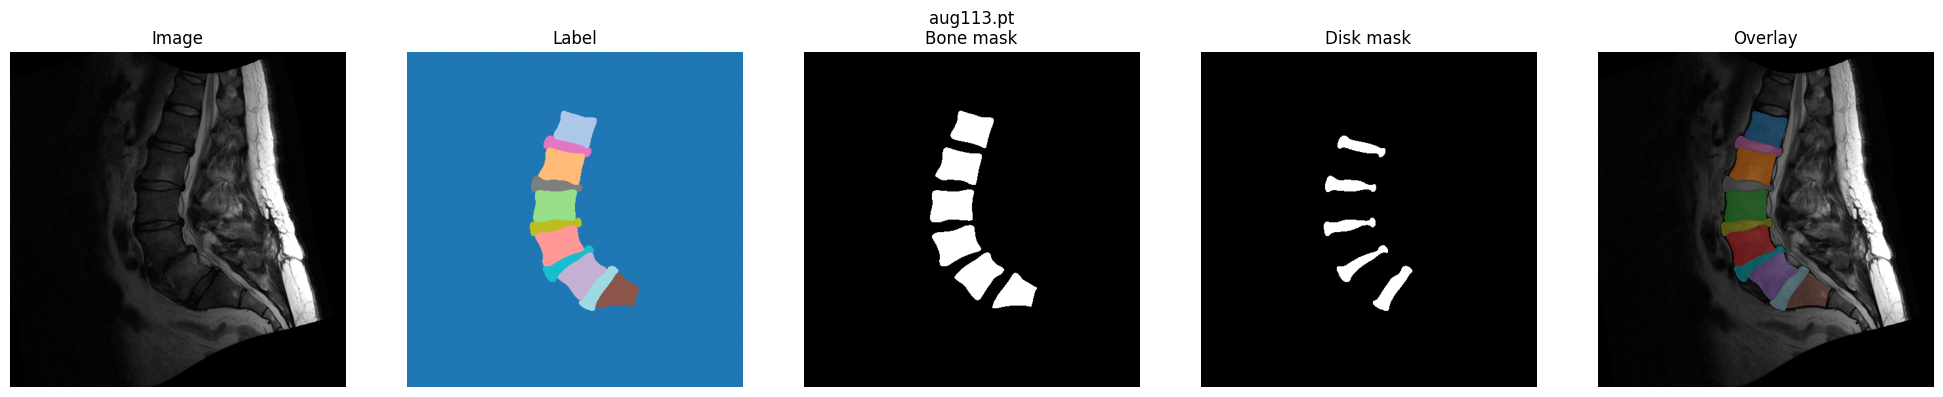

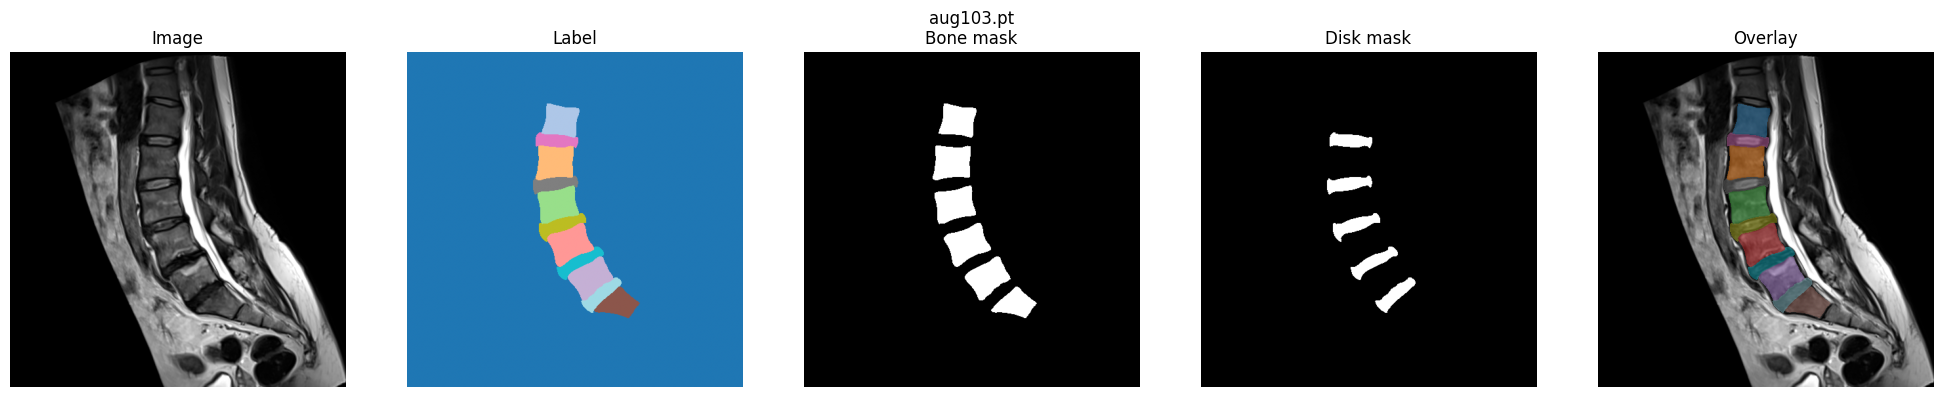

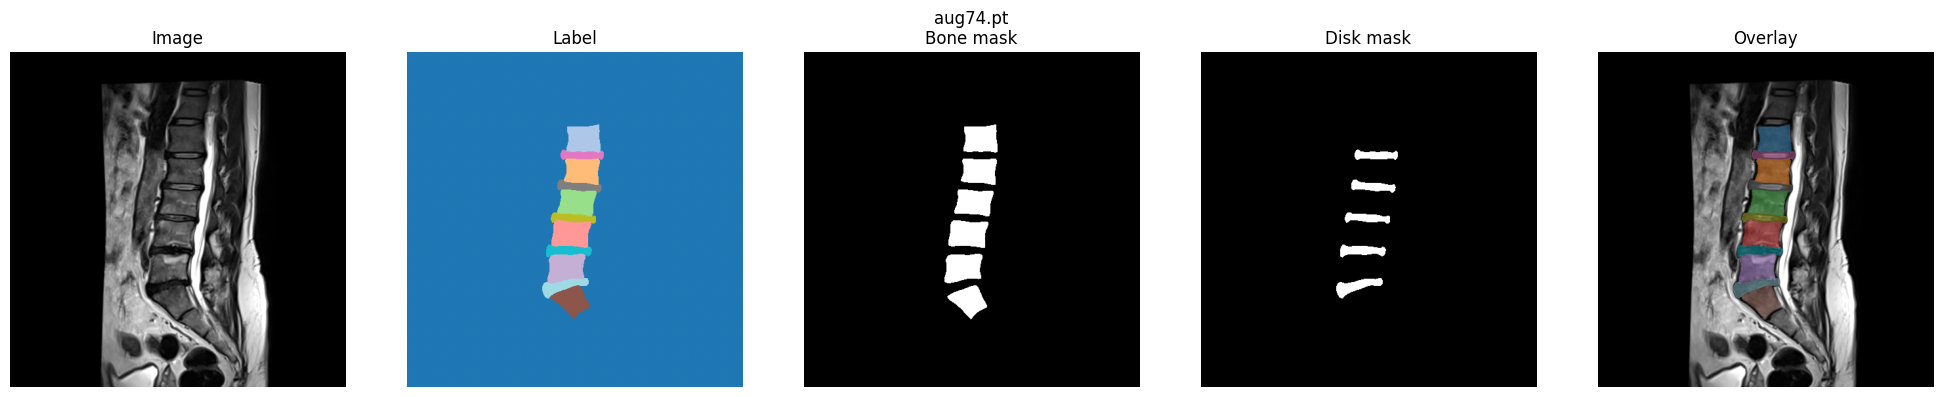

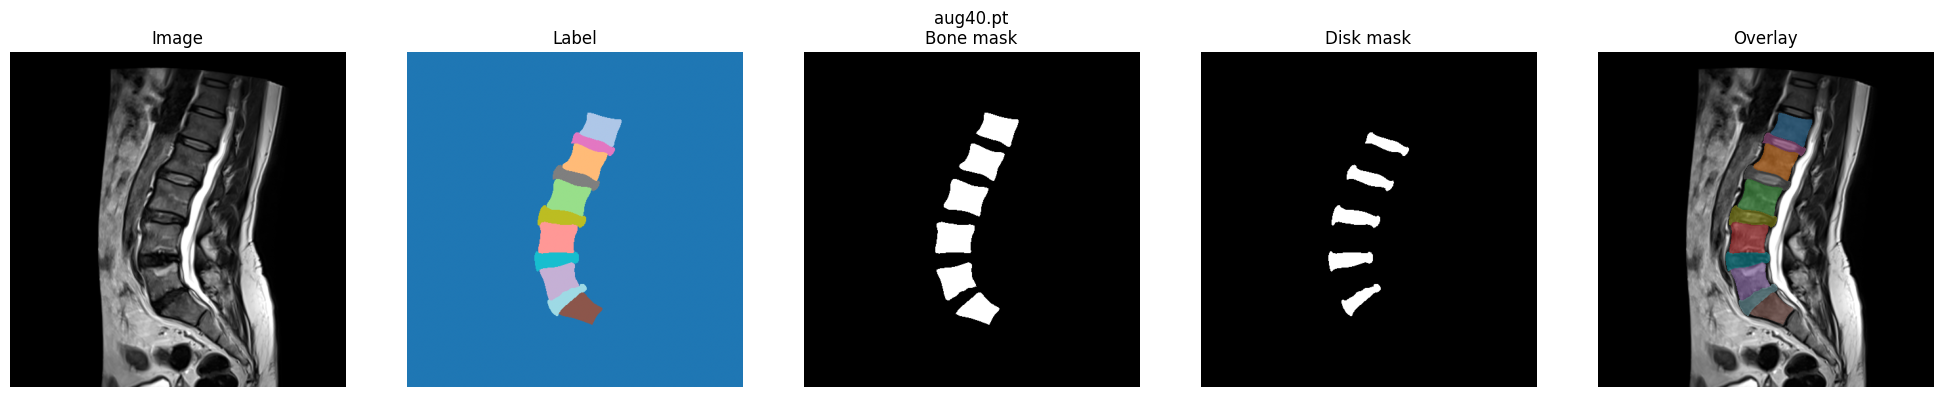

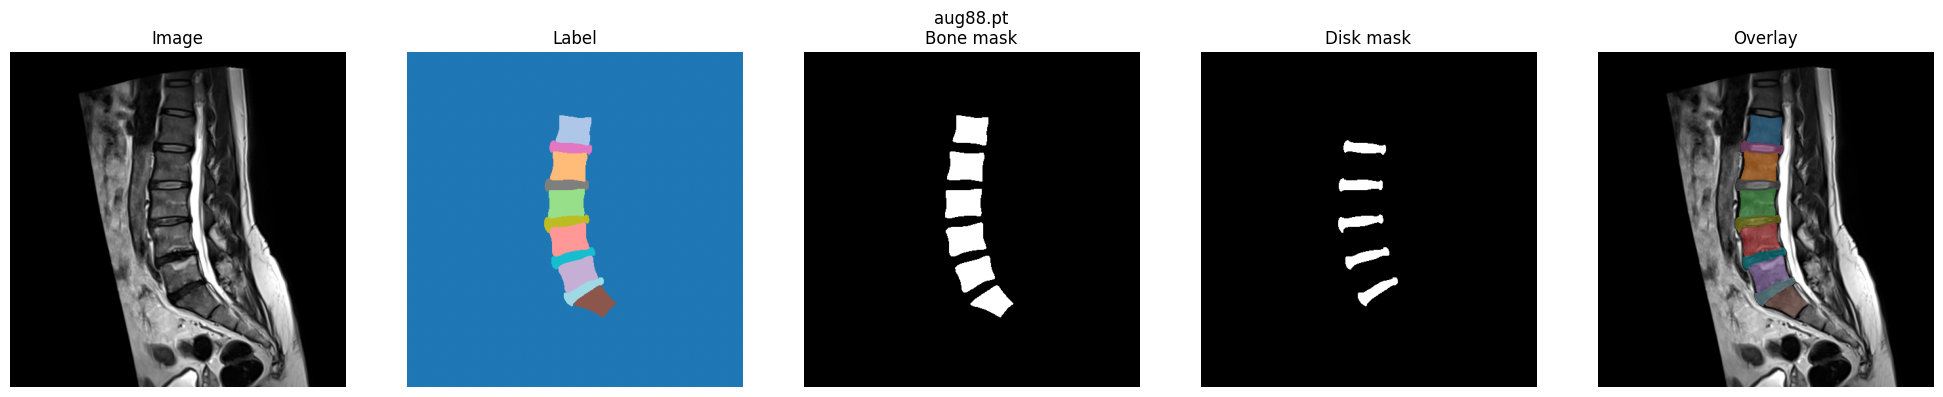

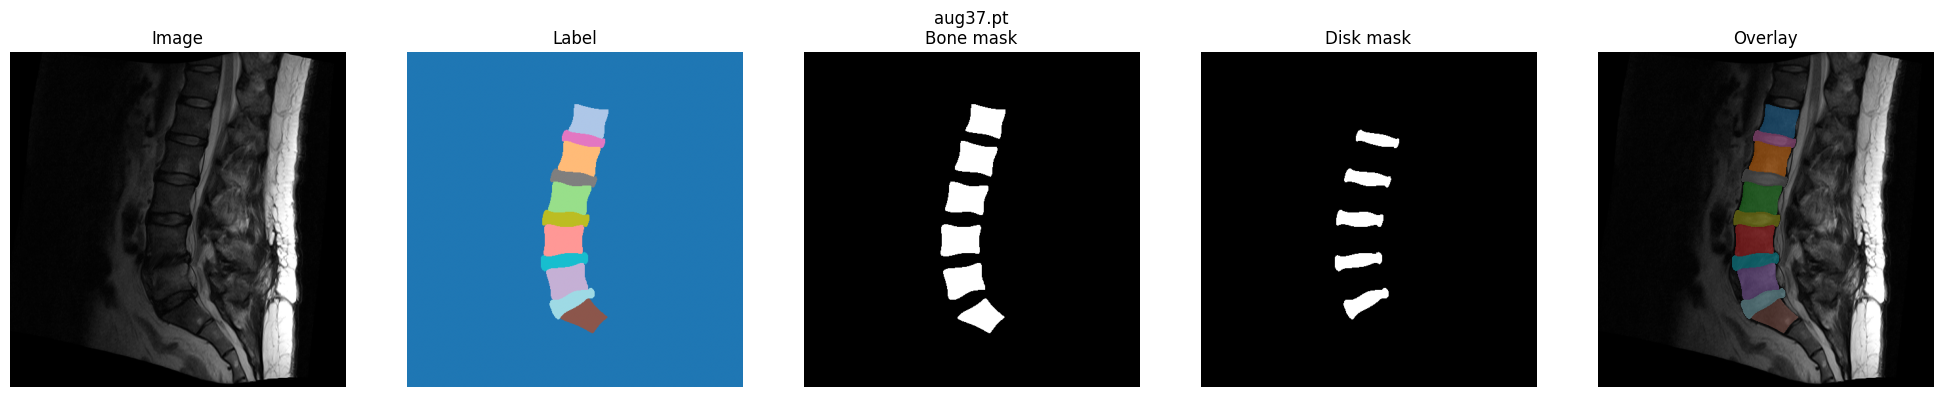

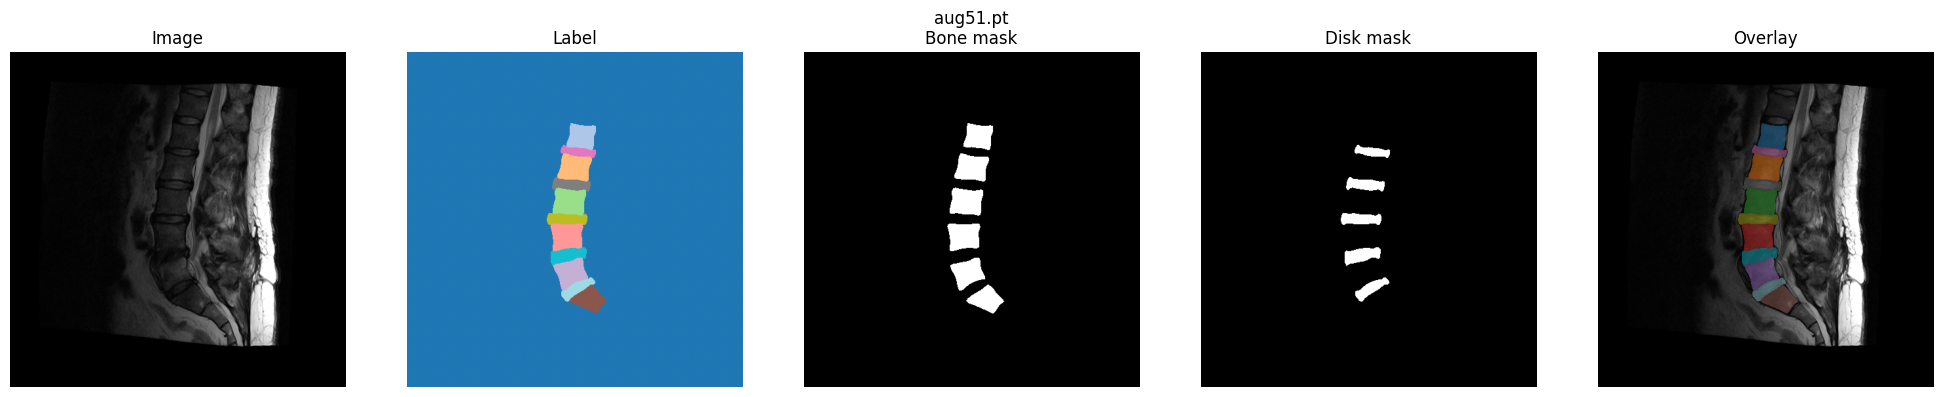

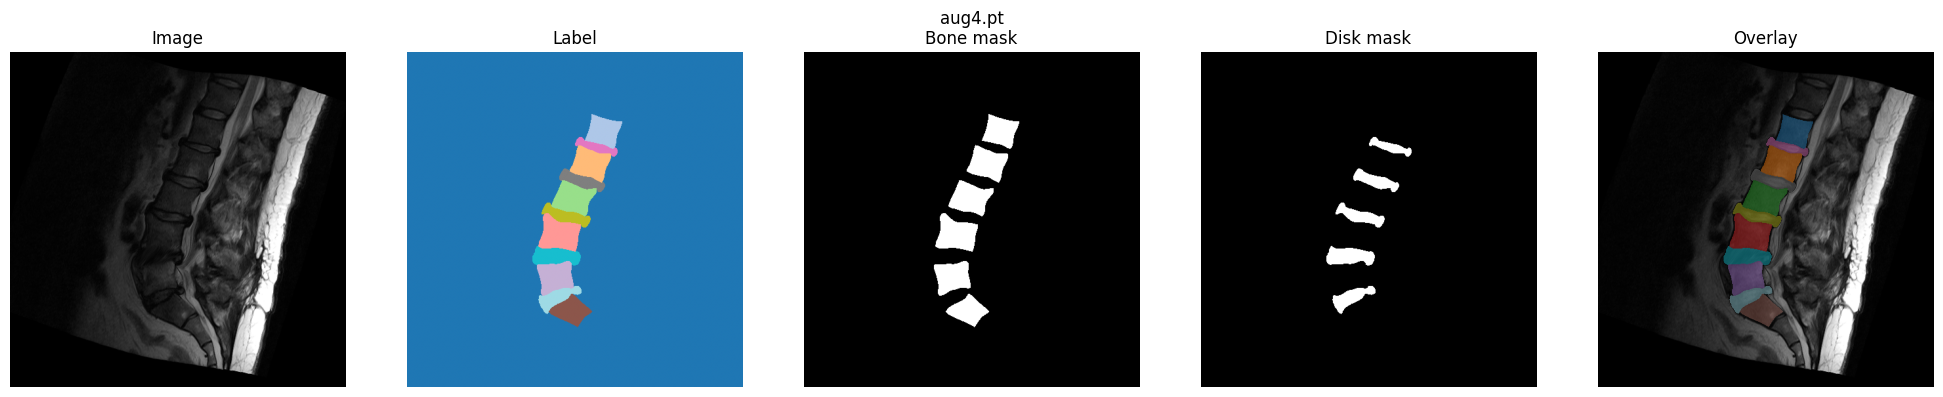

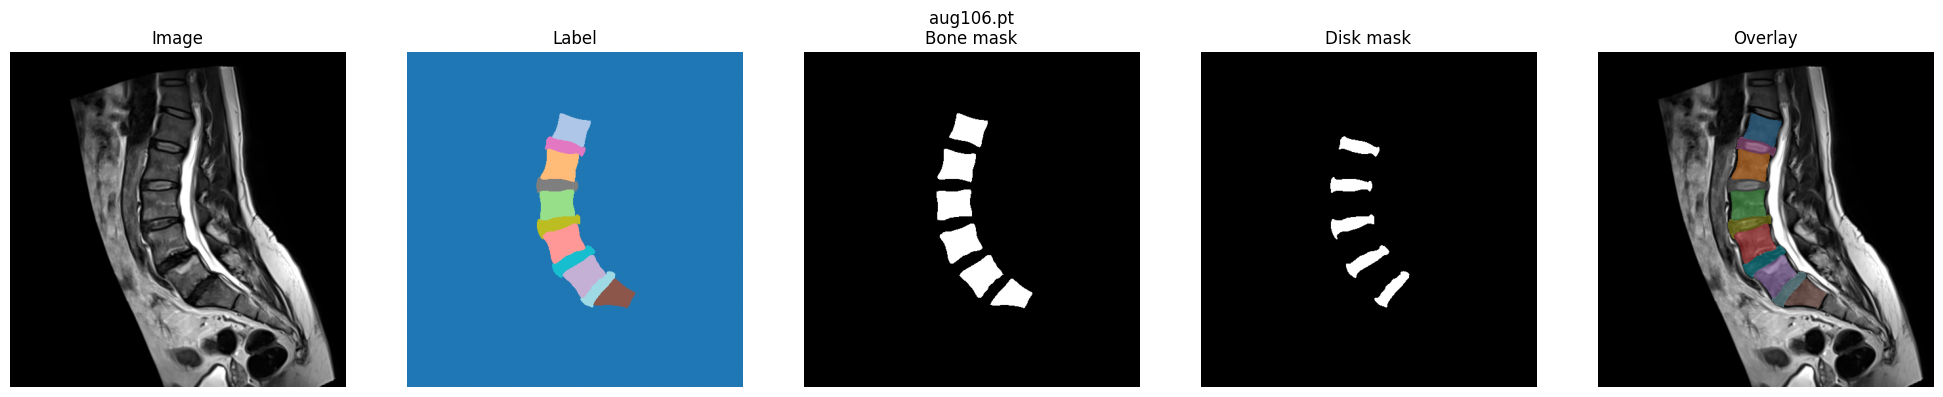

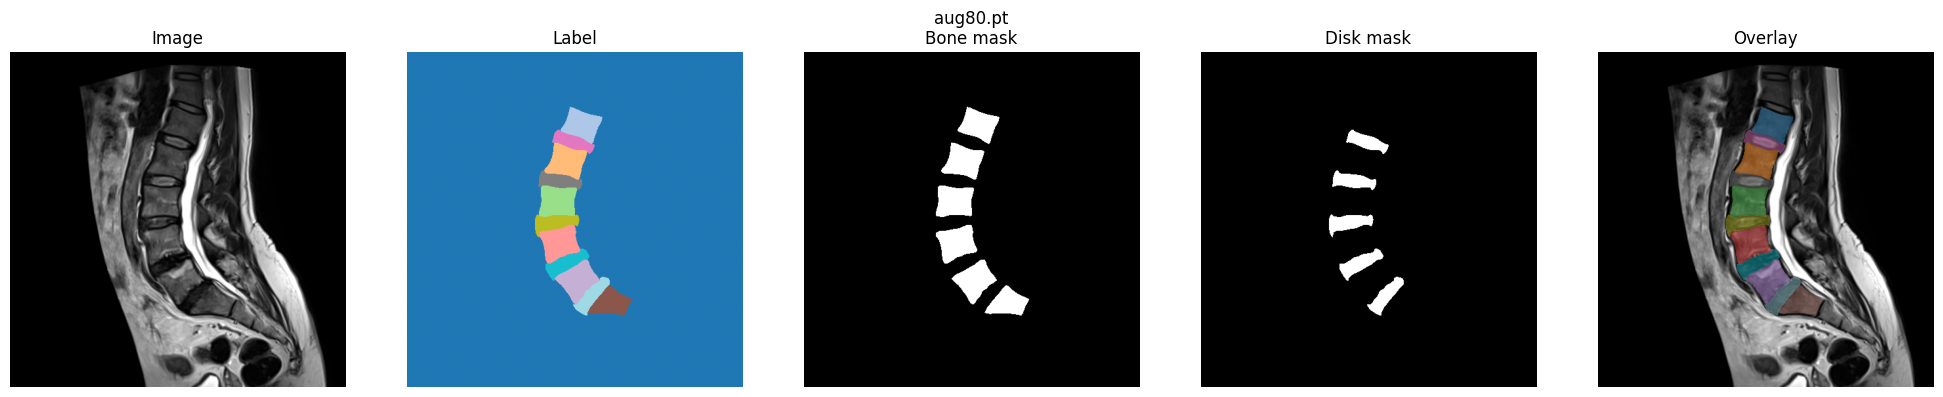

Figuras exportadas:
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_01.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_02.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_03.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_04.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_05.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_06.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_07.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_08.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_09.png
- /content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_10.png


In [12]:
def arr2d(value):
    arr = to_numpy(value)

    if arr is None:
        return None

    arr = np.asarray(arr)

    # Remover dimensiones unitarias
    arr = np.squeeze(arr)

    # Si queda con canales, tomar el primero o combinar
    if arr.ndim == 3:
        # Si es C,H,W
        if arr.shape[0] <= 20:
            arr = arr[0]
        # Si es H,W,C
        elif arr.shape[-1] <= 20:
            arr = arr[..., 0]

    if arr.ndim != 2:
        return None

    return arr

def normalize_image(img):
    img = np.asarray(img).astype(np.float32)

    if img.size == 0:
        return img

    p1, p99 = np.percentile(img, [1, 99])

    if p99 <= p1:
        return np.zeros_like(img, dtype=np.float32)

    img = np.clip(img, p1, p99)
    img = (img - p1) / (p99 - p1 + 1e-8)

    return img

def combine_channel_mask(value):
    arr = to_numpy(value)

    if arr is None:
        return None

    arr = np.asarray(arr)
    arr = np.squeeze(arr)

    if arr.ndim == 2:
        return arr

    if arr.ndim == 3:
        # C,H,W
        if arr.shape[0] <= 20:
            return arr.max(axis=0)
        # H,W,C
        if arr.shape[-1] <= 20:
            return arr.max(axis=-1)

    return None

figure_paths = []

vis_samples = loaded_samples[:VIS_SAMPLE_N]

for idx, (row_info, data) in enumerate(vis_samples, start=1):
    if not isinstance(data, dict):
        continue

    img = None

    for key in ["img", "img_corrected", "img_equalized"]:
        if key in data:
            img = arr2d(data[key])
            if img is not None:
                break

    label = arr2d(data["label"]) if "label" in data else None
    bone_mask = combine_channel_mask(data["bone_mask"]) if "bone_mask" in data else None
    disk_mask = combine_channel_mask(data["disk_mask"]) if "disk_mask" in data else None
    full_mask = combine_channel_mask(data["mask"]) if "mask" in data else None

    if img is None:
        continue

    img_norm = normalize_image(img)

    overlay_source = label
    if overlay_source is None:
        overlay_source = full_mask
    if overlay_source is None:
        overlay_source = disk_mask
    if overlay_source is None:
        overlay_source = bone_mask

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(img_norm, cmap="gray")
    axes[0].set_title("Image")

    if label is not None:
        axes[1].imshow(label, cmap="tab20")
        axes[1].set_title("Label")
    else:
        axes[1].axis("off")
        axes[1].set_title("No label")

    if bone_mask is not None:
        axes[2].imshow(bone_mask, cmap="gray")
        axes[2].set_title("Bone mask")
    else:
        axes[2].axis("off")
        axes[2].set_title("No bone_mask")

    if disk_mask is not None:
        axes[3].imshow(disk_mask, cmap="gray")
        axes[3].set_title("Disk mask")
    else:
        axes[3].axis("off")
        axes[3].set_title("No disk_mask")

    axes[4].imshow(img_norm, cmap="gray")
    if overlay_source is not None:
        axes[4].imshow(np.ma.masked_where(overlay_source <= 0, overlay_source), alpha=0.45, cmap="tab20")
    axes[4].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(Path(row_info["relative_path"]).name)
    fig.tight_layout()

    fig_path = FIGURES_ROOT / f"E7_ssmspine_sample_{idx:02d}.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    figure_paths.append(str(fig_path))

print("Figuras exportadas:")
for p in figure_paths:
    print("-", p)

## Analisis de labels

In [13]:
label_rows = []

label_sample_df = (
    pt_files_df.sample(
        n=min(LABEL_SAMPLE_N, len(pt_files_df)),
        random_state=RANDOM_SEED
    )
    if len(pt_files_df)
    else pd.DataFrame()
)

for _, row in tqdm(label_sample_df.iterrows(), total=len(label_sample_df), desc="Analizando labels"):
    item = {
        "file_path": row["file_path"],
        "relative_path": row["relative_path"],
        "read_ok": False,
        "error": None,
    }

    try:
        data = torch_load_safe(row["file_path"])

        if not isinstance(data, dict):
            item["error"] = "root_not_dict"
            label_rows.append(item)
            continue

        label = arr2d(data["label"]) if "label" in data else None

        if label is None:
            item["has_label"] = False
            item["unique_labels"] = None
            item["foreground_ratio"] = None
        else:
            unique_values, counts = np.unique(label, return_counts=True)
            total = counts.sum()

            ratios = {
                int(v): float(c / total)
                for v, c in zip(unique_values, counts)
                if total > 0
            }

            item["has_label"] = True
            item["label_shape"] = str(tuple(label.shape))
            item["unique_labels"] = json.dumps([int(v) for v in unique_values.tolist()])
            item["foreground_ratio"] = float((label > 0).mean())
            item["class_ratios"] = json.dumps(ratios)

        for mask_key in ["mask", "bone_mask", "disk_mask"]:
            if mask_key in data:
                m = combine_channel_mask(data[mask_key])
                item[f"has_{mask_key}"] = True
                item[f"{mask_key}_shape"] = str(tuple(np.asarray(data[mask_key]).shape))
                item[f"{mask_key}_foreground_ratio"] = float((m > 0).mean()) if m is not None else None
            else:
                item[f"has_{mask_key}"] = False
                item[f"{mask_key}_shape"] = None
                item[f"{mask_key}_foreground_ratio"] = None

        item["read_ok"] = True

    except Exception as exc:
        item["error"] = repr(exc)

    label_rows.append(item)

label_distribution_df = pd.DataFrame(label_rows)

label_distribution_csv_path = RESULTS_ROOT / "E7_ssmspine_label_distribution.csv"
label_distribution_df.to_csv(label_distribution_csv_path, index=False)

display(label_distribution_df.head())

if len(label_distribution_df) and "unique_labels" in label_distribution_df.columns:
    print("Resumen foreground ratio:")
    display(label_distribution_df["foreground_ratio"].describe())

Analizando labels:   0%|          | 0/100 [00:00<?, ?it/s]

,file_path,relative_path,read_ok,error,has_label,label_shape,unique_labels,foreground_ratio,class_ratios,has_mask,mask_shape,mask_foreground_ratio,has_bone_mask,bone_mask_shape,bone_mask_foreground_ratio,has_disk_mask,disk_mask_shape,disk_mask_foreground_ratio
0,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Test_Sample/SSMSpine_Test_Sample/p80/...,True,None,True,"(512, 512)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",0.084091,"{""0"": 0.9159088134765625, ""1"": 0.0093231201171...",True,"(11, 512, 512)",0.084091,True,"(6, 512, 512)",0.060833,True,"(5, 512, 512)",0.023258
1,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,True,"(512, 512)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",0.078644,"{""0"": 0.921356201171875, ""1"": 0.00844192504882...",True,"(11, 512, 512)",0.078644,True,"(6, 512, 512)",0.055145,True,"(5, 512, 512)",0.023510
2,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,True,"(512, 512)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",0.060692,"{""0"": 0.9393081665039062, ""1"": 0.0073509216308...",True,"(11, 512, 512)",0.060692,True,"(6, 512, 512)",0.044594,True,"(5, 512, 512)",0.016102
3,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,True,"(512, 512)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",0.073074,"{""0"": 0.9269256591796875, ""1"": 0.0076942443847...",True,"(11, 512, 512)",0.073074,True,"(6, 512, 512)",0.049301,True,"(5, 512, 512)",0.023792
4,/content/drive/MyDrive/PFI_MVP/data/SSMSPINE/e...,SSMSpine_Train_Sample/SSMSpine_Train_Sample/p0...,True,None,True,"(512, 512)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",0.065647,"{""0"": 0.9343528747558594, ""1"": 0.0076293945312...",True,"(11, 512, 512)",0.065647,True,"(6, 512, 512)",0.047188,True,"(5, 512, 512)",0.018475


Resumen foreground ratio:


,foreground_ratio
count,100.000000
mean,0.074386
std,0.016993
min,0.042385
25%,0.060219
50%,0.072760
75%,0.084357
max,0.116444


## Evaluacion de orientacion y utilidad axial

In [14]:
n_pt = int(len(pt_files_df))
n_loaded_ok = int(pt_sample_summary_df["read_ok"].sum()) if len(pt_sample_summary_df) and "read_ok" in pt_sample_summary_df.columns else 0

all_keys = set()

for _, data in loaded_samples:
    if isinstance(data, dict):
        all_keys.update([str(k) for k in data.keys()])

has_dicom_metadata = any(
    "dicom" in k.lower()
    or "orientation" in k.lower()
    or "spacing" in k.lower()
    or "affine" in k.lower()
    for k in all_keys
)

has_segmentation_masks = any(k in all_keys for k in ["label", "mask", "bone_mask", "disk_mask"])

# Criterio conservador:
# SSMSpine usa .pt sintéticos 2D y no tiene metadata DICOM/orientación.
# Por estructura esperada de vértebras/discos visibles, se considera mid-sagittal.
appears_2d_synthetic = bool(n_pt > 0 and not has_dicom_metadata)
appears_mid_sagittal = bool(has_segmentation_masks and appears_2d_synthetic)
appears_axial = False

if appears_axial:
    recommended_use = "usable_for_axial_segmentation"
elif appears_mid_sagittal and has_segmentation_masks:
    recommended_use = "usable_for_sagittal_segmentation_or_pretraining"
elif has_segmentation_masks:
    recommended_use = "usable_for_pretraining_or_benchmark"
else:
    recommended_use = "not_useful_for_current_scope"

orientation_assessment = {
    "appears_2d_synthetic": appears_2d_synthetic,
    "appears_mid_sagittal": appears_mid_sagittal,
    "appears_axial": appears_axial,
    "has_dicom_metadata": bool(has_dicom_metadata),
    "has_segmentation_masks": bool(has_segmentation_masks),
    "n_pt_files": n_pt,
    "n_loaded_ok_sample": n_loaded_ok,
    "keys_observed": sorted(list(all_keys)),
    "recommended_use": recommended_use,
}

orientation_assessment_path = RESULTS_ROOT / "E7_ssmspine_orientation_assessment.json"

with open(orientation_assessment_path, "w", encoding="utf-8") as f:
    json.dump(orientation_assessment, f, indent=2, ensure_ascii=False)

print(json.dumps(orientation_assessment, indent=2, ensure_ascii=False))

{
  "appears_2d_synthetic": true,
  "appears_mid_sagittal": true,
  "appears_axial": false,
  "has_dicom_metadata": false,
  "has_segmentation_masks": true,
  "n_pt_files": 250,
  "n_loaded_ok_sample": 20,
  "keys_observed": [
    "bone",
    "bone_mask",
    "disk",
    "disk_mask",
    "img",
    "img_corrected",
    "img_equalized",
    "label",
    "mask",
    "shape"
  ],
  "recommended_use": "usable_for_sagittal_segmentation_or_pretraining"
}


## Reporte JSON y conclusion

In [15]:
technical_decision = orientation_assessment["recommended_use"]

report = {
    "dataset": "SSMSpine / SymTC",
    "root": str(SSMSPINE_ROOT),
    "zips_detected": int(zip_files_df["detected"].sum()) if len(zip_files_df) else 0,
    "sample_zips_detected": int(zip_files_df[zip_files_df["expected_sample"]]["detected"].sum()) if len(zip_files_df) else 0,
    "files_extracted": int(len(extracted_inventory_df)),
    "pt_files": int(len(pt_files_df)),
    "pt_sample_loaded_ok": n_loaded_ok,
    "figures": figure_paths,
    "orientation_assessment": orientation_assessment,
    "technical_decision": technical_decision,
    "exports": {
        "zip_files": str(zip_files_csv_path),
        "zip_inventory": str(zip_inventory_csv_path),
        "extraction_report": str(extraction_report_csv_path),
        "extracted_inventory": str(extracted_inventory_csv_path),
        "pt_sample_summary": str(pt_sample_summary_csv_path),
        "schema_validation": str(schema_validation_csv_path),
        "label_distribution": str(label_distribution_csv_path),
        "orientation_assessment": str(orientation_assessment_path),
    },
    "recommendation": None,
}

if technical_decision == "usable_for_axial_segmentation":
    report["recommendation"] = "Puede explorarse como dataset axial de segmentación."
elif technical_decision == "usable_for_sagittal_segmentation_or_pretraining":
    report["recommendation"] = "No resuelve axial. Puede servir como dataset sagital sintético adicional, preentrenamiento o benchmark."
elif technical_decision == "usable_for_pretraining_or_benchmark":
    report["recommendation"] = "Puede servir como benchmark/preentrenamiento, pero no como solución axial directa."
else:
    report["recommendation"] = "No se recomienda para el alcance actual."

report_path = RESULTS_ROOT / "E7_ssmspine_inventory_report.json"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

conclusion_lines = [
    "# E7 - Inventario SSMSpine / SymTC",
    "",
    "## Objetivo",
    "",
    "Evaluar SSMSpine/SymTC como posible dataset adicional para segmentación lumbar, especialmente ante la necesidad de incorporar automatización del plano axial en el producto.",
    "",
    "## Resultados principales",
    "",
    f"- ZIPs detectados: {report['zips_detected']}.",
    f"- ZIPs sample detectados: {report['sample_zips_detected']} de {len(EXPECTED_SAMPLE_ZIPS)}.",
    f"- Archivos extraídos: {report['files_extracted']}.",
    f"- Archivos `.pt` detectados: {report['pt_files']}.",
    f"- Muestras `.pt` cargadas correctamente: {report['pt_sample_loaded_ok']}.",
    f"- Máscaras de segmentación detectadas: {orientation_assessment['has_segmentation_masks']}.",
    f"- Metadata DICOM/orientación detectada: {orientation_assessment['has_dicom_metadata']}.",
    f"- Evidencia de plano axial: {orientation_assessment['appears_axial']}.",
    f"- Evidencia de plano mid-sagittal/sintético: {orientation_assessment['appears_mid_sagittal']}.",
    "",
    "## Decisión técnica",
    "",
    f"`{technical_decision}`",
    "",
    "## Interpretación",
    "",
]

if technical_decision == "usable_for_sagittal_segmentation_or_pretraining":
    conclusion_lines.extend([
        "SSMSpine contiene máscaras de segmentación y puede ser útil como dataset sintético adicional para segmentación sagital, preentrenamiento o benchmark. Sin embargo, no se considera una solución directa para automatizar el plano axial, ya que no presenta metadata DICOM ni evidencia de orientación axial clínica.",
    ])
elif technical_decision == "usable_for_axial_segmentation":
    conclusion_lines.extend([
        "SSMSpine muestra evidencia suficiente para ser evaluado como dataset axial de segmentación. Se recomienda continuar con un baseline axial.",
    ])
else:
    conclusion_lines.extend([
        "El dataset no resuelve de forma directa la necesidad de automatización axial para el MVP. Puede documentarse como exploración complementaria.",
    ])

conclusion_lines.extend([
    "",
    "## Próximo paso sugerido",
    "",
    "Si SSMSpine no resulta axial, continuar la búsqueda de datasets axiales o considerar una estrategia alternativa basada en clasificación/grading axial, por ejemplo con RSNA/LumbarDISC.",
    "",
    "## Figuras exportadas",
    "",
])

for fig_path in figure_paths:
    conclusion_lines.append(f"- `{fig_path}`")

conclusion_md = "\n".join(conclusion_lines)

conclusion_path = DOCS_ROOT / "E7_ssmspine_inventory_conclusion.md"
conclusion_path.write_text(conclusion_md, encoding="utf-8")

print("Reporte:", report_path)
print("Conclusión:", conclusion_path)
print(json.dumps(report, indent=2, ensure_ascii=False))

Reporte: /content/drive/MyDrive/PFI_MVP/results/E7_ssmspine_inventory/E7_ssmspine_inventory_report.json
Conclusión: /content/drive/MyDrive/PFI_MVP/docs/E7_ssmspine_inventory_conclusion.md
{
  "dataset": "SSMSpine / SymTC",
  "root": "/content/drive/MyDrive/PFI_MVP/data/SSMSPINE",
  "zips_detected": 2,
  "sample_zips_detected": 2,
  "files_extracted": 250,
  "pt_files": 250,
  "pt_sample_loaded_ok": 20,
  "figures": [
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_01.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_02.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_03.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_04.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_05.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_06.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_07.png",
    "/content/drive/MyDrive/PFI_MVP/figures/E7_ssmspine_sample_08.png",
   

## Criterio de aceptacion

Este notebook detecta ZIPs sample, extrae samples, inventaria `.pt`, intenta cargar muestras con `torch.load`, identifica keys/shapes, visualiza imagen + mascara, analiza labels, decide explicitamente si sirve para axial, exporta CSV/JSON/Markdown y no entrena modelos.